<a href="https://colab.research.google.com/github/fadeeva/Jump_Diffusion/blob/main/1_GBM_vs_Jump_Diffusion/GBM_vs_Jump_Diffusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
plt.style.use('ggplot')

In [3]:
rng = np.random.default_rng(42)

# GBM vs Jump Diffusion

## GBM simulation using the Euler-Maruyama method

Classic:

$
dS_t = \mu S_t dt + \sigma S_t dW_t
$

$ $

Discrete:

$
S_{t+\Delta t} = S_t + \mu S_t \Delta t + \sigma S_t \sqrt{\Delta t} Z
$

where:

$ Z \sim \mathcal{N}(0, 1)$

$ \Delta t  $ - time step

In [ ]:
T = 1.0
N = 1_000
dt = T / N
S0 = 1.0

mu = 0.1
sigma = 0.2

t = np.linspace(0, T, N + 1)
S = np.zeros(N + 1)
S[0] = S0

for i in range(N):
    Z = np.random.randn()
    dW = np.sqrt(dt) * Z

    S[i+1] = S[i] + mu*S[i]*dt + sigma*S[i]*dW


Text(0, 0.5, 'S(t)')

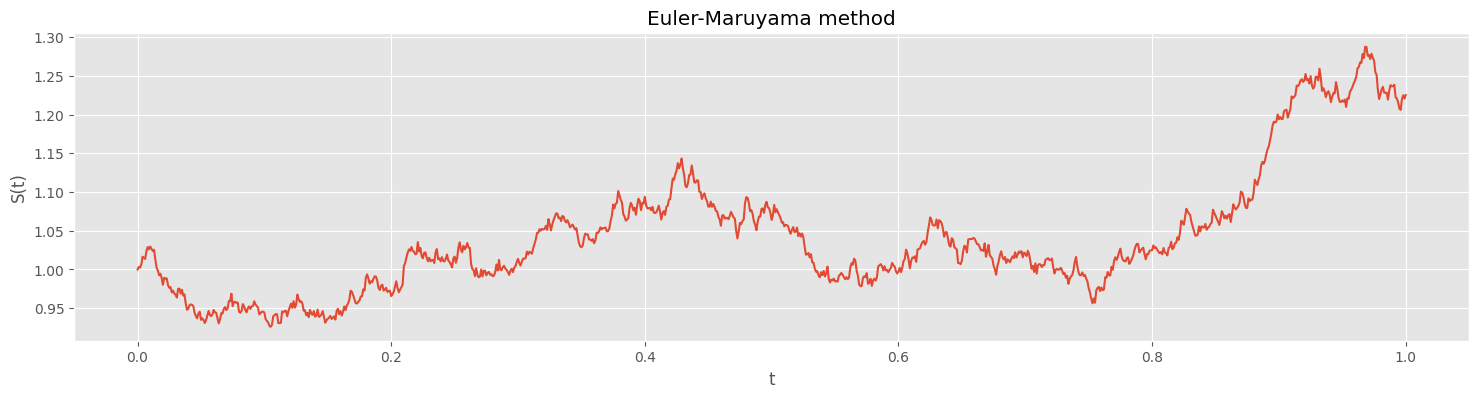

In [ ]:
plt.figure(figsize=(18, 4))

plt.plot(t, S)
plt.title('Euler-Maruyama method')
plt.xlabel('t')
plt.ylabel('S(t)')

## Merton Model

Classic:

$
dS_t = \mu S_t dt + \sigma S_t dW_t + S_t dJ_t
$

$  $

Discrete:

$
S_{t+\Delta t} = S_t \cdot exp((\mu - \frac{\sigma^2}{2} - \lambda \kappa)\Delta t + \sigma \sqrt {\Delta t} Z) \cdot Jump
$

where $ \kappa = E[Y - 1] $ risk-neutral correction

In [8]:
T = 1.0
N = 1_000
dt = T / N
S0 = 1.0

mu = 0.1
sigma = 0.2

lamb, mu_J, sigma_J = .5, -.05, .1

t = np.linspace(0, T, N + 1)
S = np.zeros(N + 1)
S[0] = S0

kappa = np.exp(mu_J + 0.5*sigma_J**2) - 1
drift_corrected = mu - 0.5*sigma**2 - lamb*kappa

for i in range(N):
    dt_sqrt = np.sqrt(dt)
    Z = np.random.randn()
    diff = drift_corrected*dt + sigma*dt_sqrt*Z

    dN = np.random.poisson(lamb*dt)

    Y = np.exp(mu_J + sigma_J*np.random.normal(0, 1))
    jump_factor = np.power(Y, dN)

    S[i+1] = S[i] * np.exp(diff) * jump_factor


Text(0, 0.5, 'S(t)')

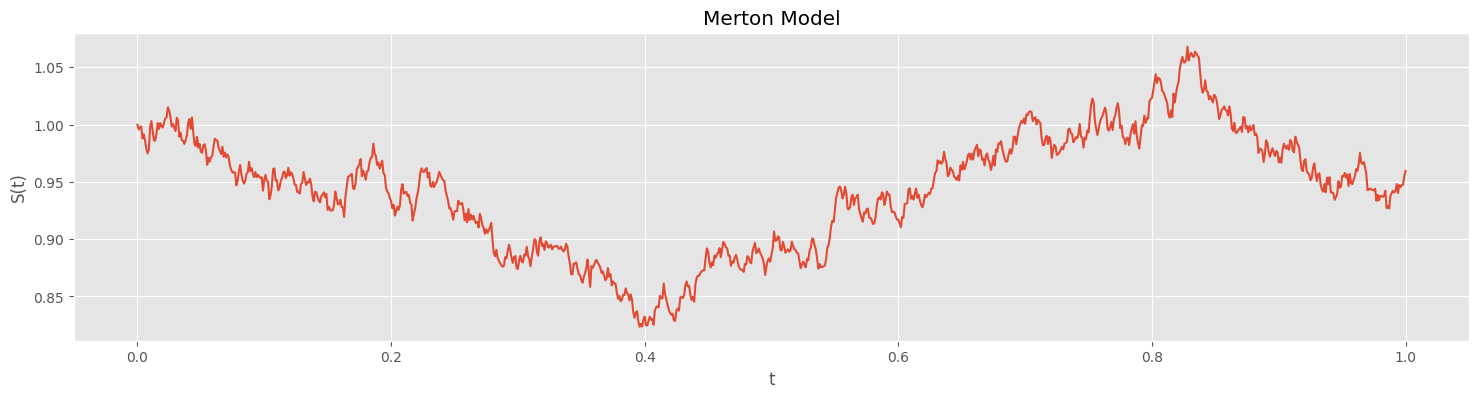

In [10]:
plt.figure(figsize=(18, 4))

plt.plot(t, S)
plt.title('Merton Model')
plt.xlabel('t')
plt.ylabel('S(t)')